# Note: this notebook generates the UMAPs in Figure 8.  See https://github.com/vanbreugel-lab/SplitFlowOptoTracking/blob/main/TrajectorySimulations/universal_search_algo.ipynb for generating the trajectories and visualizing samples associated with Figure 8



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D  
import figurefirst as fifi
import seaborn as sns
###
import sys
sys.path.insert(1, '../../../Code')
from PlotUtilities import *
from FeatureFunctions import *



from tsfresh import defaults, extract_features
from tsfresh.feature_selection.relevance import calculate_relevance_table
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import MinimalFCParameters #
 
import umap


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


# Set params and load FiFi template

In [2]:
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']

plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'


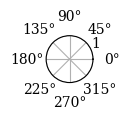

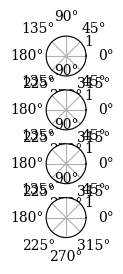

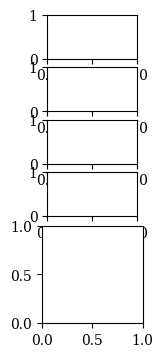

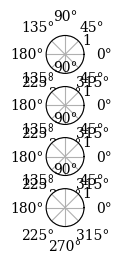

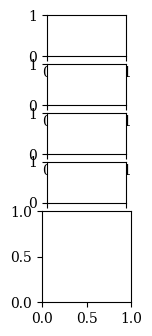

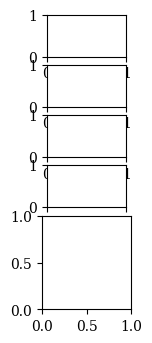

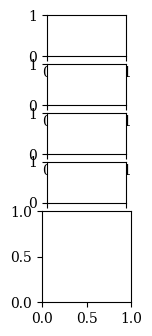

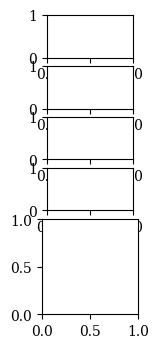

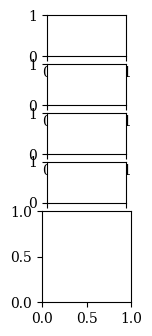

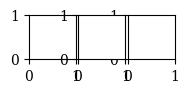

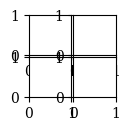

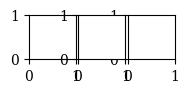

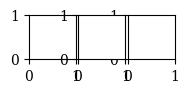

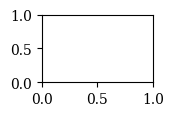

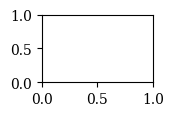

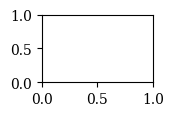

In [185]:
layout = fifi.svg_to_axes.FigureLayout('../unifying_algo_vertical.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])



# Laminar - Control

In [29]:
lam_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/training_laminar_df.hdf')

lam_df = get_normed_positions(lam_df)

# Still air

In [108]:
nw_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/training_nw_df.hdf')
nw_df = get_normed_positions(nw_df)


# Simulations

In [167]:
sims = pd.read_hdf('../../../Data/universal_algorithm_trajectories.hdf')

In [190]:
sims

,x,y,xvel,yvel,windtype,obj_id,time stamp,heading,z
0,0.003362,-0.001505,0.327015,-0.165957,laminar,0,-100.0,-0.469623,0
1,0.006632,-0.003165,0.309032,-0.182586,laminar,0,-90.0,-0.533649,0
2,0.009636,-0.005083,0.291742,-0.200973,laminar,0,-80.0,-0.603219,0
3,0.012513,-0.007151,0.283712,-0.212635,laminar,0,-70.0,-0.643166,0
4,0.015392,-0.009247,0.292134,-0.206659,laminar,0,-60.0,-0.615684,0
...,...,...,...,...,...,...,...,...,...
485,0.021252,-0.211620,-0.242184,-0.126338,stillair,599,4750.0,-2.660768,0
486,0.018863,-0.212875,-0.235542,-0.124537,stillair,599,4760.0,-2.655231,0
487,0.016540,-0.214113,-0.229167,-0.123084,stillair,599,4770.0,-2.648712,0
488,0.014279,-0.215336,-0.223030,-0.121527,stillair,599,4780.0,-2.642680,0


In [168]:
sims = sims.rename(columns={'x_pos':'x','y_pos':'y','x_vel':'xvel','y_vel':'yvel', 'timestamp':'time stamp'})

In [169]:
sims.loc[:, 'time stamp'] = np.round(sims['time stamp']*1000)
sims.loc[:, 'time stamp'] = sims['time stamp'].astype(int)
sims['heading']=np.arctan2(sims['yvel'],sims['xvel'])
sims['z']=0

In [170]:
casting_sims=sims[sims.windtype=='laminar']
casting_sims.loc[:,'obj_id_unique']=casting_sims['obj_id'].astype(str) + '_laminar'
casting_sims = get_normed_pos_groupby(casting_sims)
unsteady_sims=sims[sims.windtype=='unsteady']
unsteady_sims.loc[:,'obj_id_unique']=unsteady_sims['obj_id'].astype(str) + '_unsteady'
unsteady_sims = get_normed_pos_groupby(unsteady_sims)
circle_sims=sims[sims.windtype=='stillair']
circle_sims.loc[:,'obj_id_unique']=circle_sims['obj_id'].astype(str) + '_stillair'
circle_sims = get_normed_pos_groupby(circle_sims)

/tmp/ipykernel_6611/1920055896.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  casting_sims.loc[:,'obj_id_unique']=casting_sims['obj_id'].astype(str) + '_laminar'
/tmp/ipykernel_6611/1920055896.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unsteady_sims.loc[:,'obj_id_unique']=unsteady_sims['obj_id'].astype(str) + '_unsteady'
/tmp/ipykernel_6611/1920055896.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

# Features; UMAP

In [171]:
dfs = [lam_df,
    nw_df,
      casting_sims,
       unsteady_sims,
       circle_sims]

In [172]:
dfs = calculate_features(dfs, start_time=1100)

df # 0
Culled 6 trajectories
n trajs: 312
df # 1
Culled 1 trajectories
n trajs: 251
df # 2
Culled 0 trajectories
n trajs: 200
df # 3
Culled 0 trajectories
n trajs: 200
df # 4
Culled 0 trajectories
n trajs: 200


In [173]:
all_dfs = pd.concat(dfs)

In [174]:
X = extract_features(all_dfs[['xvel','yvel', 'normed_x_680', 'normed_y_680','obj_id_unique','time stamp']].dropna(), 
                         column_id='obj_id_unique', column_sort='time stamp',
                         #default_fc_parameters=ComprehensiveFCParameters(),
                         default_fc_parameters=MinimalFCParameters(),
                     impute_function=impute)

# these are just the length of each time series, not relevant features
X = X.drop(columns=['xvel__length','yvel__length','normed_x_680__length','normed_y_680__length'])


2025-02-09 12:52:21,566 [WARNING] Dependency not available for matrix_profile, this feature will be disabled!
Feature Extraction: 100%|██████████████████████████████████████████████████████████| 80/80 [00:00<00:00, 87.59it/s]


In [175]:
cmap_sim = plt.get_cmap('BrBG', 16) 
cmap_real = plt.get_cmap('RdBu', 16) 


df_colors = [cmap_real(1),
             cmap_real(15),
            cmap_sim(2),
             'purple',
             cmap_sim(14),
            ]



'''
df_colors = [cmap_real(1),
             cmap_real(15),

             'darkorange',
            cmap_real(13),
             cmap_real(3),#cmap_real(6),
            cmap_real(11),]
'''



df_labels = ['Laminar', #0
             'Still Air', #1
            'Casting Sim', #2
                   'Unsteady Sim', #8
            'Circling Sim', #3 
] 


df_features_list = []



feature_names = ['circle_cross', 
                 'hull_area', 
                 'hull_roundness', 

                 'heading_derivative_absmean',
                 'heading_difference_sliding_absmean',]


for i, df in enumerate(dfs):
    df['dataset_name'] = df_labels[i]
    
    #df =df.assign(color=df.apply(lambda x: df_colors[i], 1))
    df_features = df.groupby('obj_id_unique')['dataset_name'].first()
    
    
    for feature_name in feature_names:
        df_tmp = np.abs( df.groupby('obj_id_unique')[feature_name].mean() )
        df_features = pd.concat([df_features, df_tmp], axis=1)
    df_features['class']=i
    df_features =df_features.assign(color=df_features.apply(lambda x: df_colors[i], 1))
    df_features_list.append(df_features)
    
df_features = pd.concat(df_features_list)

In [176]:
dfs_important_feats = df_features.join(X)

In [177]:
training_data = dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])].drop(columns=['dataset_name', 'color','class',])#+ irrel_mann)#+ irrel_feats)
y_classes =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])]['class'] 
df_pvalues_mann = calculate_relevance_table(training_data,y_classes, fdr_level=0.05, hypotheses_independent=False)
irrel_feats_mannu=list(df_pvalues_mann [df_pvalues_mann['p_value']>0.05].feature.values)

In [178]:
irrel_feats_mannu

['normed_y_680__mean', 'normed_y_680__sum_values', 'normed_y_680__median']

# Import Model Trained on Lam + Still Air Data

In [179]:
import pickle
f_name = '../../../Code/UMAP_trained.sav'
trained_model = pickle.load((open(f_name, 'rb')))
print(type(trained_model))


<class 'umap.umap_.UMAP'>


In [180]:
training_data = dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])].sort_index().drop(columns=['dataset_name', 'color','class', ] + irrel_feats_mannu)
training_data  =StandardScaler().fit_transform(training_data.values)
y_classes =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])]['class'].sort_index() 
y_colors =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Laminar', 'Still Air',])]['color'].sort_index() 



X_test = dfs_important_feats[dfs_important_feats.dataset_name.isin(['Casting Sim', 'Circling Sim', 'Unsteady Sim' ])].sort_index().drop(columns=['dataset_name', 'color','class', ]  + irrel_feats_mannu)
X_test  =StandardScaler().fit_transform(X_test.values)

y_test =  dfs_important_feats[dfs_important_feats.dataset_name.isin(['Casting Sim', 'Circling Sim', 'Unsteady Sim'])]['color'].sort_index()

test_embedding = trained_model.transform(X_test)


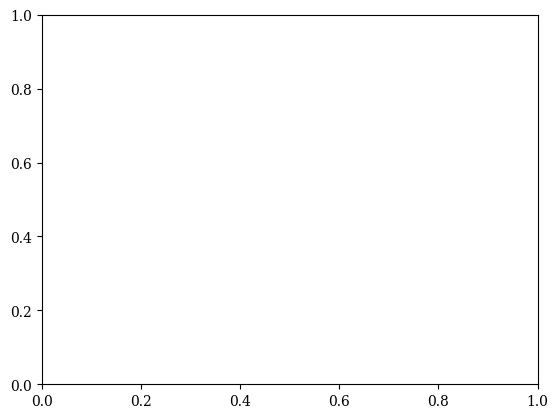

In [186]:
plottingdf = dfs_important_feats[dfs_important_feats.dataset_name.isin([ 'Casting Sim', 'Circling Sim','Unsteady Sim' ])].sort_index().copy()#.drop(columns=['dataset_name', 'color','class', ]+ irrel_feats+irrel_feats_lam).copy()
plottingdf['embedding_x'] = test_embedding[:, 0]
plottingdf['embedding_y'] =test_embedding[:, 1]



fig, ax = plt.subplots()

ax = layout.axes[('laminar_features', 'umap')]
sns.kdeplot(x=trained_model.embedding_[:, 0], y=trained_model.embedding_[:, 1], hue=y_colors, levels=3, thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

legend_labels = []

i= 'Casting Sim'
ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color,)
legend_labels.append(Line2D([0], [0],marker='d', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))

 
ax.set_xlim(1,13)
ax.set_ylim(7,13)
ax.set_aspect('equal')

#ax.set_rasterized(True)
#ax.legend(loc='upper left', handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.axis('off')
layout.append_figure_to_layer(layout.figures['laminar_features'], 'laminar_features', cleartarget=True)


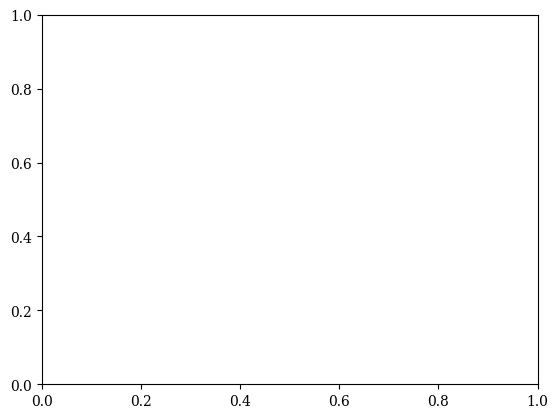

In [187]:
plottingdf = dfs_important_feats[dfs_important_feats.dataset_name.isin([ 'Casting Sim', 'Circling Sim','Unsteady Sim' ])].sort_index().copy()#.drop(columns=['dataset_name', 'color','class', ]+ irrel_feats+irrel_feats_lam).copy()
plottingdf['embedding_x'] = test_embedding[:, 0]
plottingdf['embedding_y'] =test_embedding[:, 1]



fig, ax = plt.subplots()

ax = layout.axes[('unsteady_features', 'umap')]
sns.kdeplot(x=trained_model.embedding_[:, 0], y=trained_model.embedding_[:, 1], hue=y_colors, levels=3, thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

legend_labels = []

i= 'Unsteady Sim'
ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color,)
legend_labels.append(Line2D([0], [0],marker='d', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))

 
ax.set_xlim(1,13)
ax.set_ylim(7,13)
ax.set_aspect('equal')

#ax.set_rasterized(True)
#ax.legend(loc='upper left', handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.axis('off')
layout.append_figure_to_layer(layout.figures['unsteady_features'], 'unsteady_features', cleartarget=True)


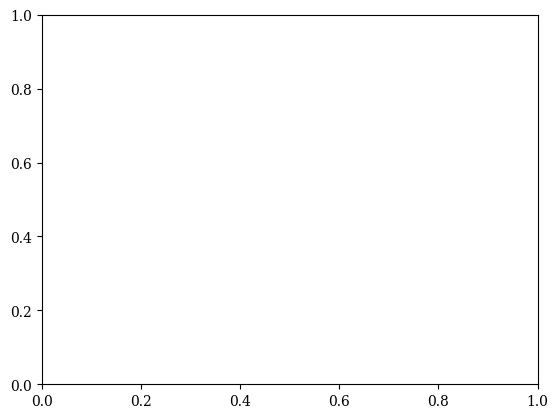

In [188]:
plottingdf = dfs_important_feats[dfs_important_feats.dataset_name.isin([ 'Casting Sim', 'Circling Sim','Unsteady Sim' ])].sort_index().copy()#.drop(columns=['dataset_name', 'color','class', ]+ irrel_feats+irrel_feats_lam).copy()
plottingdf['embedding_x'] = test_embedding[:, 0]
plottingdf['embedding_y'] =test_embedding[:, 1]



fig, ax = plt.subplots()

ax = layout.axes[('stillair_features', 'umap')]
sns.kdeplot(x=trained_model.embedding_[:, 0], y=trained_model.embedding_[:, 1], hue=y_colors, levels=3, thresh=.25,fill=True, alpha=.2, palette=list(y_colors.unique()), legend=False,ax=ax)

legend_labels = []

i= 'Circling Sim'
ax.scatter(plottingdf[plottingdf['dataset_name']==i].embedding_x,plottingdf[plottingdf['dataset_name']==i].embedding_y, s= 1, c=plottingdf[plottingdf['dataset_name']==i].color, )
legend_labels.append(Line2D([0], [0],marker='d', markersize=2, markeredgecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], markerfacecolor=plottingdf[plottingdf['dataset_name']==i].color.iloc[0], linestyle='', label=plottingdf[plottingdf['dataset_name']==i].dataset_name.iloc[0]))

 
ax.set_xlim(1,13)
ax.set_ylim(7,13)
ax.set_aspect('equal')

#ax.set_rasterized(True)
#ax.legend(loc='upper left', handles=legend_labels)# orange_patch, yellow_patch, blue_patch, cyan_patch,black_patch],)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.axis('off')
layout.append_figure_to_layer(layout.figures['stillair_features'],'stillair_features', cleartarget=True)

# Save Figure

In [189]:
layout.write_svg('f8_discussion.svg')